In [1]:
# ============================================================
# CELL 1 — Kaggle Setup & Imports
# ============================================================
import kagglehub
briscdataset_brisc2025_path = kagglehub.dataset_download('briscdataset/brisc2025')
print('Data source import complete.')

!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.3
!pip install -q opencv-contrib-python-headless
!pip install -q onnxscript

import os, glob, random, warnings, hashlib
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Data source import complete.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.5/109.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.5 MB/s eta 0:00:00
Device: cuda


In [2]:
# ============================================================
# CELL 2 — Paths & Data Loading
# ============================================================
DATA_ROOT      = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
SEG_TRAIN_IMG  = os.path.join(DATA_ROOT, "segmentation_task", "train", "images")
SEG_TRAIN_MASK = os.path.join(DATA_ROOT, "segmentation_task", "train", "masks")
SEG_TEST_IMG   = os.path.join(DATA_ROOT, "segmentation_task", "test",  "images")
SEG_TEST_MASK  = os.path.join(DATA_ROOT, "segmentation_task", "test",  "masks")

IMG_SIZE = 224
MEAN     = np.array([0.485, 0.456, 0.406])
STD      = np.array([0.229, 0.224, 0.225])

def build_seg_df(img_dir, mask_dir):
    rows = []
    for img_path in sorted(glob.glob(os.path.join(img_dir, "*.jpg"))):
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, stem + ".png")
        if os.path.exists(mask_path):
            rows.append({"img_path": img_path, "mask_path": mask_path})
    return pd.DataFrame(rows)

seg_train_df = build_seg_df(SEG_TRAIN_IMG, SEG_TRAIN_MASK)
seg_test_df  = build_seg_df(SEG_TEST_IMG,  SEG_TEST_MASK)
print("Seg train:", len(seg_train_df), "| Seg test:", len(seg_test_df))

def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Checking for data leakage between train and test images...")
train_hashes = {file_hash(p): p for p in seg_train_df["img_path"]}
duplicates   = [p for p in seg_test_df["img_path"] if file_hash(p) in train_hashes]
print(f"Duplicates found: {len(duplicates)}")
seg_test_df = seg_test_df[~seg_test_df["img_path"].isin(duplicates)].reset_index(drop=True)
print(f"Test after cleaning: {len(seg_test_df)}")

Seg train: 3933 | Seg test: 860
Checking for data leakage between train and test images...
Duplicates found: 7
Test after cleaning: 853


In [3]:
# ============================================================
# CELL 3 — Feature Functions & CLAHE-RGB Helper
# ============================================================

def feat_clahe(gray):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    out   = clahe.apply(gray)
    return out.astype(np.float32) / 255.0

def feat_sobel(gray):
    sx  = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.clip(mag / mag.max() if mag.max() > 0 else mag, 0, 1)
    return mag.astype(np.float32)

def feat_laplacian(gray):
    lap = cv2.Laplacian(gray, cv2.CV_64F)
    lap = np.abs(lap)
    lap = np.clip(lap / lap.max() if lap.max() > 0 else lap, 0, 1)
    return lap.astype(np.float32)

def feat_gabor(gray, ksize=21, sigma=4, theta=np.pi/4, lambd=10, gamma=0.5):
    kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, lambd, gamma, 0, ktype=cv2.CV_32F)
    out    = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, kernel)
    out    = np.abs(out)
    out    = out / out.max() if out.max() > 0 else out
    return out.astype(np.float32)

def feat_harris(gray):
    gray_f = np.float32(gray)
    dst    = cv2.cornerHarris(gray_f, blockSize=2, ksize=3, k=0.04)
    dst    = np.clip(dst / dst.max() if dst.max() > 0 else dst, 0, 1)
    return dst.astype(np.float32)

def feat_canny(gray):
    edges = cv2.Canny(gray, 50, 150)
    return edges.astype(np.float32) / 255.0

def feat_sift_density(gray):
    sift    = cv2.SIFT_create()
    kps     = sift.detect(gray, None)
    heatmap = np.zeros(gray.shape, dtype=np.float32)
    for kp in kps:
        x, y = int(kp.pt[0]), int(kp.pt[1])
        if 0 <= y < gray.shape[0] and 0 <= x < gray.shape[1]:
            heatmap[y, x] += kp.response
    heatmap = cv2.GaussianBlur(heatmap, (0, 0), sigmaX=5)
    heatmap = heatmap / heatmap.max() if heatmap.max() > 0 else heatmap
    return heatmap

def feat_dog(gray, k=1.6, sigma=1.0):
    g1  = cv2.GaussianBlur(gray.astype(np.float32), (0, 0), sigma)
    g2  = cv2.GaussianBlur(gray.astype(np.float32), (0, 0), sigma * k)
    dog = np.abs(g1 - g2)
    dog = dog / dog.max() if dog.max() > 0 else dog
    return dog.astype(np.float32)

def feat_lbp(gray, radius=1, n_points=8):
    from skimage.feature import local_binary_pattern
    lbp = local_binary_pattern(gray, n_points, radius, method='uniform')
    lbp = lbp / lbp.max() if lbp.max() > 0 else lbp
    return lbp.astype(np.float32)

def apply_clahe_rgb(img_uint8: np.ndarray) -> np.ndarray:
    """Apply CLAHE on the L channel of LAB, return RGB uint8."""
    lab     = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l       = clahe.apply(l)
    lab     = cv2.merge([l, a, b])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

FEATURE_REGISTRY = {
    "clahe":        feat_clahe,
    "sobel":        feat_sobel,
    "laplacian":    feat_laplacian,
    "gabor":        feat_gabor,
    "harris":       feat_harris,
    "canny":        feat_canny,
    "sift_density": feat_sift_density,
    "dog":          feat_dog,
    "lbp":          feat_lbp,
}

print("Available features:", list(FEATURE_REGISTRY.keys()))

Available features: ['clahe', 'sobel', 'laplacian', 'gabor', 'harris', 'canny', 'sift_density', 'dog', 'lbp']


In [4]:
# ============================================================
# CELL 4 — Post-processing: Morphology & Region Growing
# ============================================================

def apply_morphology(mask: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    m = (mask * 255).astype(np.uint8)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE,  kernel)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,   kernel)
    m = cv2.dilate(m, kernel, iterations=1)
    return (m > 127).astype(np.uint8)


def apply_region_growing(image_gray: np.ndarray, seed_mask: np.ndarray,
                          tolerance: int = 15) -> np.ndarray:
    from collections import deque
    h, w      = image_gray.shape
    visited   = seed_mask.copy().astype(bool)
    result    = seed_mask.copy().astype(bool)

    seed_pixels = image_gray[visited]
    if len(seed_pixels) == 0:
        return seed_mask

    mean_intensity = float(seed_pixels.mean())
    queue          = deque(zip(*np.where(visited)))
    neighbors      = [(-1,0),(1,0),(0,-1),(0,1)]

    while queue:
        y, x = queue.popleft()
        for dy, dx in neighbors:
            ny, nx = y + dy, x + dx
            if 0 <= ny < h and 0 <= nx < w and not visited[ny, nx]:
                visited[ny, nx] = True
                if abs(int(image_gray[ny, nx]) - mean_intensity) <= tolerance:
                    result[ny, nx] = True
                    queue.append((ny, nx))

    return result.astype(np.uint8)


def refine_mask(pred_mask: np.ndarray, image_gray: np.ndarray,
                use_morphology: bool = True,
                use_region_growing: bool = False,
                morph_kernel_size: int = 5,
                region_grow_tolerance: int = 15) -> np.ndarray:
    mask = pred_mask.copy()
    if use_morphology:
        mask = apply_morphology(mask, kernel_size=morph_kernel_size)
    if use_region_growing:
        mask = apply_region_growing(image_gray, mask, tolerance=region_grow_tolerance)
    return mask

print("Post-processing helpers defined (morphology + region growing).")

Post-processing helpers defined (morphology + region growing).


In [5]:
# ============================================================
# CELL 5 — ⚙️ CONFIGURATION CELL (edit this each run)
# ============================================================
INPUT_MODE = "rgb"       # "rgb" | "feature"

FEATURE_A = "clahe"      # ignored when INPUT_MODE = "rgb"
FEATURE_B = "sobel"      # ignored when INPUT_MODE = "rgb"

SEG_MODEL_NAME      = "UNet-ResNet34"
LR_ENCODER          = 1e-4
LR_DECODER          = 1e-3
WEIGHT_DECAY        = 1e-4
TOTAL_EPOCHS        = 50
EARLY_STOP_PATIENCE = 10

# ── Post-processing flags ───────────────────────────────────
USE_MORPHOLOGY     = False   # apply morphological close/open/dilate
USE_REGION_GROWING = False  # apply region growing seeded from mask
MORPH_KERNEL_SIZE  = 5      # structuring element size
REGION_GROW_TOL    = 15     # intensity tolerance for region growing

SEG_REGISTRY = {
    "UNet-EffB0":          (smp.Unet,          "efficientnet-b0"),
    "UNet-ResNet34":       (smp.Unet,          "resnet34"),
    "UNetPP-EffB0":        (smp.UnetPlusPlus,  "efficientnet-b0"),
    "UNetPP-ResNet34":     (smp.UnetPlusPlus,  "resnet34"),
    "DeepLabV3P-EffB0":    (smp.DeepLabV3Plus, "efficientnet-b0"),
    "DeepLabV3P-ResNet50": (smp.DeepLabV3Plus, "resnet50"),
    "FPN-EffB0":           (smp.FPN,           "efficientnet-b0"),
    "MAnet-EffB0":         (smp.MAnet,         "efficientnet-b0"),
}

assert INPUT_MODE in ("rgb", "feature"), f"INPUT_MODE must be 'rgb' or 'feature', got '{INPUT_MODE}'"
if INPUT_MODE == "feature":
    assert FEATURE_A in FEATURE_REGISTRY, f"Unknown FEATURE_A: '{FEATURE_A}'"
    assert FEATURE_B in FEATURE_REGISTRY, f"Unknown FEATURE_B: '{FEATURE_B}'"
    print(f"Config: gray + {FEATURE_A} + {FEATURE_B} | Model: {SEG_MODEL_NAME}")
else:
    print(f"Config: RGB+CLAHE | Model: {SEG_MODEL_NAME}")
print(f"LR encoder={LR_ENCODER} | LR decoder={LR_DECODER} | Epochs={TOTAL_EPOCHS} | Patience={EARLY_STOP_PATIENCE}")
print(f"Post-processing: morphology={USE_MORPHOLOGY} | region_growing={USE_REGION_GROWING}")

Config: RGB+CLAHE | Model: UNet-ResNet34
LR encoder=0.0001 | LR decoder=0.001 | Epochs=50 | Patience=10
Post-processing: morphology=False | region_growing=False


In [6]:
# ============================================================
# CELL 6 — Feature Cache & Generation
# ============================================================
_FEATURE_CACHE = {}

def get_feature(img_path: str, feature_name: str, target_size: int) -> np.ndarray:
    key = (img_path, feature_name, target_size)
    if key in _FEATURE_CACHE:
        return _FEATURE_CACHE[key]
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(gray, (target_size, target_size))
    feat = FEATURE_REGISTRY[feature_name](gray)
    _FEATURE_CACHE[key] = feat
    return feat

def build_3ch_image(img_path: str, feat_a: str, feat_b: str, target_size: int) -> np.ndarray:
    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    gray = cv2.resize(gray, (target_size, target_size))
    ch0  = gray.astype(np.float32) / 255.0
    ch1  = get_feature(img_path, feat_a, target_size)
    ch2  = get_feature(img_path, feat_b, target_size)
    return np.stack([ch0, ch1, ch2], axis=-1)

print("Feature cache and builder ready.")

Feature cache and builder ready.


In [7]:
# ============================================================
# CELL 7 — Augmentations & Datasets
# ============================================================
seg_aug_train = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

seg_aug_test = A.Compose([
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class BrainSegDataset(Dataset):
    def __init__(self, df, input_mode, feat_a=None, feat_b=None, transform=None):
        self.df         = df.reset_index(drop=True)
        self.input_mode = input_mode
        self.feat_a     = feat_a
        self.feat_b     = feat_b
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.input_mode == "rgb":
            img = cv2.imread(row["img_path"])
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = apply_clahe_rgb(img)
        else:
            img_f = build_3ch_image(row["img_path"], self.feat_a, self.feat_b, IMG_SIZE)
            img   = (img_f * 255).clip(0, 255).astype(np.uint8)

        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
        mask = (mask > 127).astype(np.uint8)

        if self.transform:
            aug       = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]

        return img, mask.long()

seg_train_ds = BrainSegDataset(seg_train_df, INPUT_MODE, FEATURE_A, FEATURE_B, seg_aug_train)
seg_test_ds  = BrainSegDataset(seg_test_df,  INPUT_MODE, FEATURE_A, FEATURE_B, seg_aug_test)

seg_train_dl = DataLoader(seg_train_ds, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
seg_test_dl  = DataLoader(seg_test_ds,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(seg_train_dl)} | Test batches: {len(seg_test_dl)}")

Train batches: 62 | Test batches: 14


In [8]:
# ============================================================
# CELL 8 — Model Helpers
# ============================================================
def unfreeze_seg_encoder(model):
    for param in model.parameters():
        param.requires_grad = True
    print("  All parameters are now trainable.")

print("Model helper defined.")

Model helper defined.


In [9]:
# ============================================================
# CELL 9 — Loss & Metrics
# ============================================================
bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def seg_criterion(pred, target):
    target_f = target.float().unsqueeze(1)
    return 0.5 * bce_loss(pred, target_f) + 0.5 * dice_loss(pred, target_f)

def compute_metrics(pred_logits, target):
    pred  = (torch.sigmoid(pred_logits) > 0.5).float()
    tgt   = target.float().unsqueeze(1)

    inter      = (pred * tgt).sum(dim=(2, 3))
    union_dice = pred.sum(dim=(2, 3)) + tgt.sum(dim=(2, 3))
    union_iou  = pred.sum(dim=(2, 3)) + tgt.sum(dim=(2, 3)) - inter

    dice = ((2 * inter + 1e-6) / (union_dice + 1e-6)).mean().item()
    iou  = ((inter + 1e-6) / (union_iou + 1e-6)).mean().item()

    return {"dice": dice, "iou": iou}

print("Loss and metrics defined.")

Loss and metrics defined.


In [10]:
# ============================================================
# CELL 10 — Train / Eval Loop Helpers
# ============================================================
def train_one_epoch_seg(model, loader, optimizer):
    model.train()
    total_loss = total_dice = total_iou = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        pred = model(imgs)
        loss = seg_criterion(pred, masks)
        loss.backward()
        optimizer.step()
        m             = compute_metrics(pred, masks)
        total_loss   += loss.item() * imgs.size(0)
        total_dice   += m["dice"]  * imgs.size(0)
        total_iou    += m["iou"]   * imgs.size(0)
        n            += imgs.size(0)
    return total_loss / n, total_dice / n, total_iou / n

@torch.no_grad()
def eval_seg(model, loader):
    model.eval()
    total_loss = total_dice = total_iou = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        pred        = model(imgs)
        m           = compute_metrics(pred, masks)
        total_loss += seg_criterion(pred, masks).item() * imgs.size(0)
        total_dice += m["dice"] * imgs.size(0)
        total_iou  += m["iou"]  * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n, total_iou / n

print("Train/eval helpers ready.")

Train/eval helpers ready.


In [11]:
# ============================================================
# CELL 11 — Build Model
# ============================================================
arch, encoder = SEG_REGISTRY[SEG_MODEL_NAME]
seg_model = arch(
    encoder_name    = encoder,
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
    activation      = None,
).to(DEVICE)

# ── Multi-GPU ───────────────────────────────────────────────
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    seg_model = nn.DataParallel(seg_model)

unfreeze_seg_encoder(seg_model)

seg_optimizer = torch.optim.AdamW([
    {"params": seg_model.module.encoder.parameters() if isinstance(seg_model, nn.DataParallel) else seg_model.encoder.parameters(), "lr": LR_ENCODER},
    {"params": seg_model.module.decoder.parameters() if isinstance(seg_model, nn.DataParallel) else seg_model.decoder.parameters(), "lr": LR_DECODER},
], weight_decay=WEIGHT_DECAY)

print(f"Model built: {SEG_MODEL_NAME} | Encoder: {encoder}")

Downloading: "https://download.pytorch.org/models/resnet34-333f7ec4.pth" to /root/.cache/torch/hub/checkpoints/resnet34-333f7ec4.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 447MB/s]


Using 2 GPUs
  All parameters are now trainable.
Model built: UNet-ResNet34 | Encoder: resnet34


In [12]:
# ============================================================
# CELL 12 — Training with Early Stopping
# ============================================================
history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou":  [], "val_iou":  [],
}

best_val_dice    = 0.0
patience_counter = 0

print(f"\n── Starting Training ──")
if INPUT_MODE != 'rgb':
    print(f"Model: {SEG_MODEL_NAME} | Features: gray + {FEATURE_A} + {FEATURE_B}")
else:
    print(f"Model: {SEG_MODEL_NAME} | RGB + CLAHE")
print(f"Total epochs: {TOTAL_EPOCHS} | Early stop patience: {EARLY_STOP_PATIENCE}\n")

for epoch in range(1, TOTAL_EPOCHS + 1):
    tr_loss, tr_dice, tr_iou = train_one_epoch_seg(seg_model, seg_train_dl, seg_optimizer)
    vl_loss, vl_dice, vl_iou = eval_seg(seg_model, seg_test_dl)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_dice"].append(tr_dice)
    history["val_dice"].append(vl_dice)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(vl_iou)

    flag = ""
    if vl_dice > best_val_dice:
        best_val_dice    = vl_dice
        torch.save(seg_model.module.state_dict() if isinstance(seg_model, nn.DataParallel) else seg_model.state_dict(), f"best_seg_{SEG_MODEL_NAME}.pth")
        flag             = " ✓"
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"[{epoch:02d}/{TOTAL_EPOCHS}] "
          f"loss={tr_loss:.4f}/{vl_loss:.4f}  "
          f"dice={tr_dice:.4f}/{vl_dice:.4f}  "
          f"iou={tr_iou:.4f}/{vl_iou:.4f}{flag}")

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

print(f"\nBest validation Dice: {best_val_dice:.4f}")


── Starting Training ──
Model: UNet-ResNet34 | RGB + CLAHE
Total epochs: 50 | Early stop patience: 10

[01/50] loss=0.6935/0.6276  dice=0.3857/0.6337  iou=0.2836/0.5204 ✓
[02/50] loss=0.6236/0.6059  dice=0.6441/0.7029  iou=0.5183/0.5870 ✓
[03/50] loss=0.6019/0.5875  dice=0.7023/0.7376  iou=0.5795/0.6303 ✓
[04/50] loss=0.5822/0.5647  dice=0.7299/0.7200  iou=0.6134/0.5961
[05/50] loss=0.5656/0.5508  dice=0.7466/0.7195  iou=0.6336/0.6000
[06/50] loss=0.5486/0.5316  dice=0.7729/0.8009  iou=0.6648/0.7024 ✓
[07/50] loss=0.5342/0.5173  dice=0.7780/0.7785  iou=0.6718/0.6709
[08/50] loss=0.5184/0.5060  dice=0.7934/0.7792  iou=0.6893/0.6718
[09/50] loss=0.5040/0.4896  dice=0.7993/0.7941  iou=0.6977/0.6917
[10/50] loss=0.4871/0.4738  dice=0.8004/0.8198  iou=0.6991/0.7288 ✓
[11/50] loss=0.4712/0.4566  dice=0.8081/0.8077  iou=0.7080/0.7118
[12/50] loss=0.4561/0.4433  dice=0.8046/0.8172  iou=0.7042/0.7251
[13/50] loss=0.4404/0.4268  dice=0.8133/0.7940  iou=0.7157/0.6908
[14/50] loss=0.4209/0.4049  

In [13]:
# ============================================================
# CELL 14 — Final Test Evaluation & Summary
# ============================================================
seg_model.module.load_state_dict(
    torch.load(f"best_seg_{SEG_MODEL_NAME}.pth", map_location="cuda")
)
_, final_dice, final_iou = eval_seg(seg_model, seg_test_dl)

print("=" * 60)
print(f"FINAL RESULTS (raw UNet, no post-processing)")
print(f"  Model          : {SEG_MODEL_NAME}")
if INPUT_MODE != 'rgb':
    print(f"  Features       : gray + {FEATURE_A} + {FEATURE_B}")
else:
    print("  Mode           : RGB + CLAHE (LAB)")
print(f"  Test Dice      : {final_dice:.4f}")
print(f"  Test IoU       : {final_iou:.4f}")
print("=" * 60)

FINAL RESULTS (raw UNet, no post-processing)
  Model          : UNet-ResNet34
  Mode           : RGB + CLAHE (LAB)
  Test Dice      : 0.8685
  Test IoU       : 0.7978


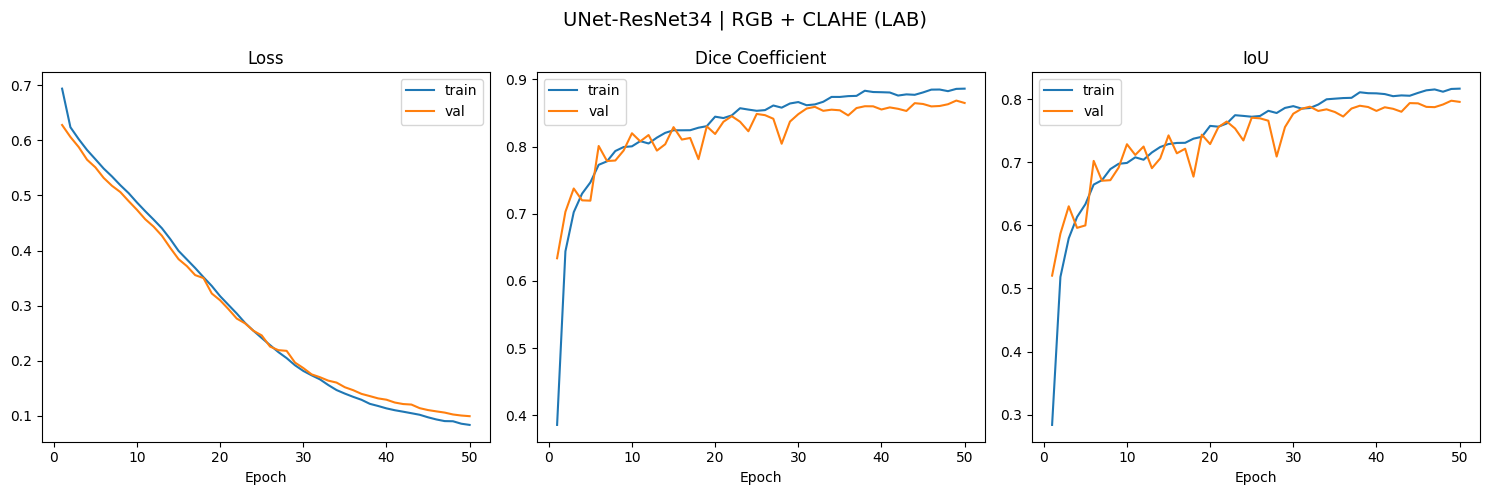

In [14]:
# ============================================================
# CELL 13 — Training Curves
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"],   label="val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs_range, history["train_dice"], label="train")
axes[1].plot(epochs_range, history["val_dice"],   label="val")
axes[1].set_title("Dice Coefficient"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(epochs_range, history["train_iou"],  label="train")
axes[2].plot(epochs_range, history["val_iou"],    label="val")
axes[2].set_title("IoU"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle(f"{SEG_MODEL_NAME} | RGB + CLAHE (LAB)", fontsize=14)
plt.tight_layout()
plt.savefig(f"seg_curves_{SEG_MODEL_NAME}.png", dpi=150)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0429412].


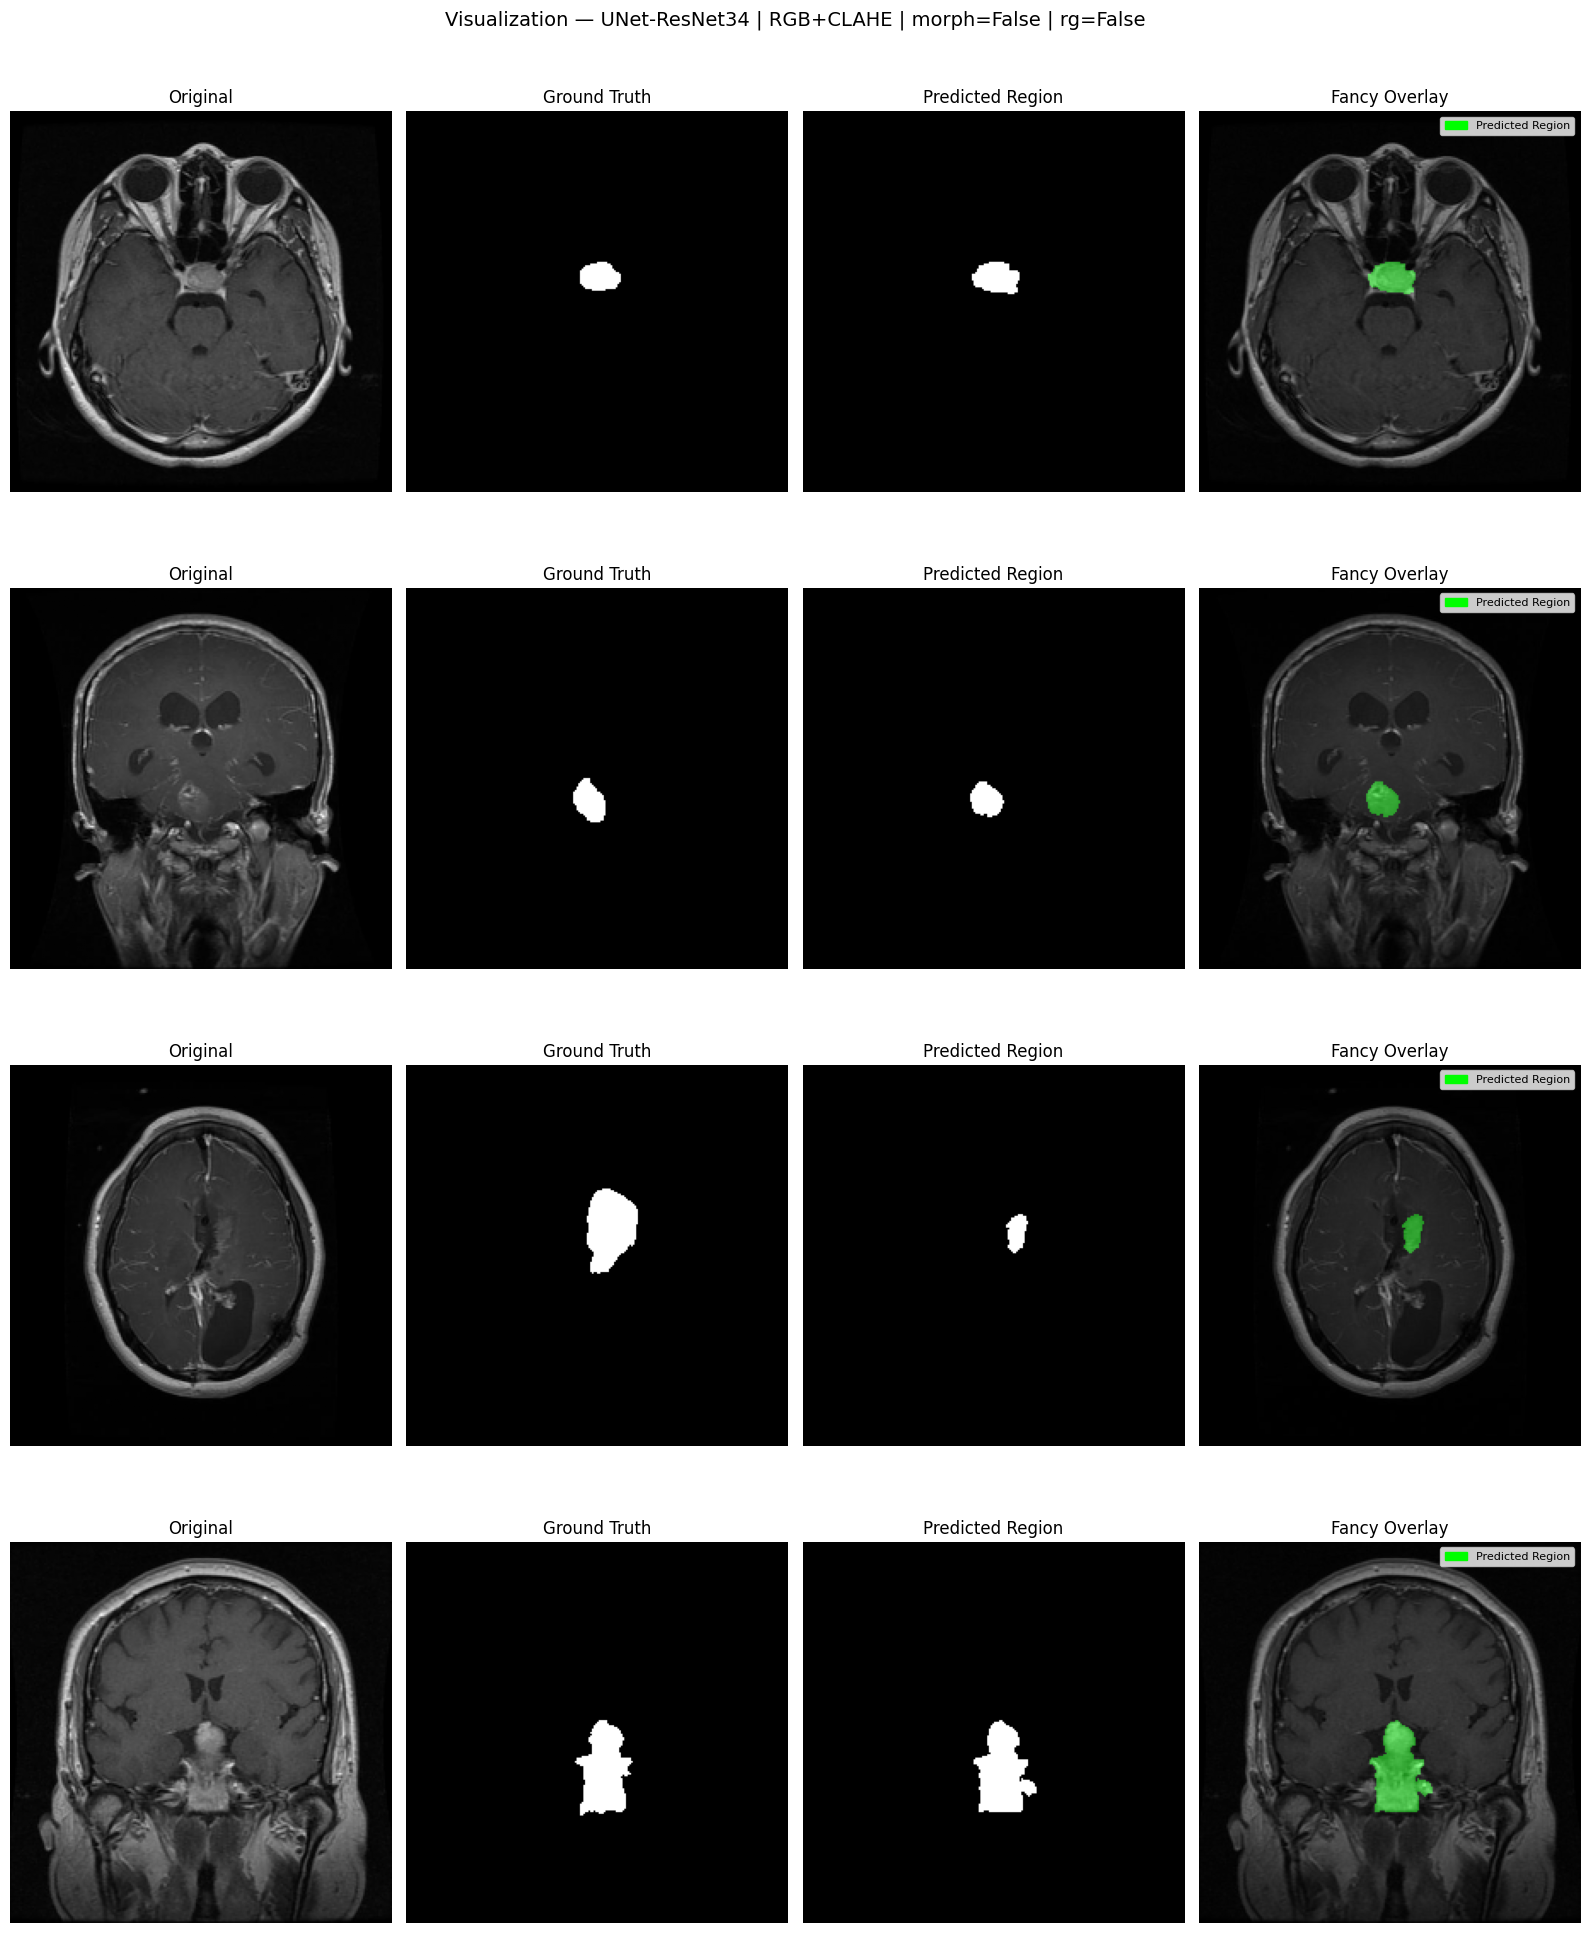

In [15]:
# ============================================================
# CELL 15 — Visualization (Clean + Mask separated)
# ============================================================
seg_model.module.load_state_dict(
    torch.load(f"best_seg_{SEG_MODEL_NAME}.pth", map_location="cuda")
)
seg_model.eval()

num_samples = 4
indices = random.sample(range(len(seg_test_ds)), num_samples)

n_cols = 4  # Original + GT + Pred Mask + Fancy Overlay

fig, axes = plt.subplots(num_samples, n_cols, figsize=(4 * n_cols, 5 * num_samples))
fig.suptitle(
    f"Visualization — {SEG_MODEL_NAME} | RGB+CLAHE | "
    f"morph={USE_MORPHOLOGY} | rg={USE_REGION_GROWING}",
    fontsize=14, y=0.995,
)

for i, idx in enumerate(indices):
    img_tensor, mask_gt = seg_test_ds[idx]
    img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pred_logits = seg_model(img_tensor)
        pred_prob = torch.sigmoid(pred_logits[0, 0]).cpu().numpy()
        pred_mask = (pred_prob > 0.5).astype(np.uint8)

    orig_path = seg_test_ds.df.iloc[idx]["img_path"]
    orig = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
    orig = cv2.resize(orig, (IMG_SIZE, IMG_SIZE))
    mask_gt_np = mask_gt.cpu().numpy()

    refined_mask = refine_mask(
        pred_mask, orig,
        use_morphology=USE_MORPHOLOGY,
        use_region_growing=USE_REGION_GROWING,
        morph_kernel_size=MORPH_KERNEL_SIZE,
        region_grow_tolerance=REGION_GROW_TOL,
    )

    rgb_base = np.stack([orig, orig, orig], axis=-1).astype(np.float32) / 255.0

    col = 0

    # Original
    axes[i, col].imshow(orig, cmap='gray')
    axes[i, col].set_title("Original")
    axes[i, col].axis('off')
    col += 1

    # Ground truth
    axes[i, col].imshow(mask_gt_np, cmap='gray')
    axes[i, col].set_title("Ground Truth")
    axes[i, col].axis('off')
    col += 1

    # Predicted region (NO overlay)
    axes[i, col].imshow(refined_mask, cmap='gray')
    axes[i, col].set_title("Predicted Region")
    axes[i, col].axis('off')
    col += 1

    # Fancy overlay (for intuition)
    green_layer = np.stack([
        np.zeros_like(refined_mask, dtype=np.float32),
        refined_mask.astype(np.float32) * 0.9,
        np.zeros_like(refined_mask, dtype=np.float32),
    ], axis=-1)

    overlay_fancy = cv2.addWeighted(rgb_base.copy(), 0.7, green_layer, 0.5, 0)

    axes[i, col].imshow(overlay_fancy)
    axes[i, col].set_title("Fancy Overlay")
    axes[i, col].axis('off')

    green_patch = mpatches.Patch(color='lime', label='Predicted Region')
    axes[i, col].legend(handles=[green_patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(f"visualization_{SEG_MODEL_NAME}.png", dpi=200, bbox_inches='tight')
plt.show()

In [16]:
# ============================================================
# CELL 16 — mIoU per Tumor Type (raw + post-processed)
# ============================================================

def extract_tumor_type(img_path: str) -> str:
    fname = os.path.basename(img_path)
    if "_gl_" in fname: return "glioma"
    if "_me_" in fname: return "meningioma"
    if "_pi_" in fname: return "pituitary"
    return "unknown"

seg_test_df["tumor_type"] = seg_test_df["img_path"].apply(extract_tumor_type)
print("Tumor type distribution:")
print(seg_test_df["tumor_type"].value_counts())

seg_model.module.load_state_dict(
    torch.load(f"best_seg_{SEG_MODEL_NAME}.pth", map_location="cuda")
)
seg_model.eval()

records = []

with torch.no_grad():
    for idx in range(len(seg_test_ds)):
        img_tensor, mask_gt = seg_test_ds[idx]
        img_tensor = img_tensor.unsqueeze(0).to(DEVICE)

        pred_logits = seg_model(img_tensor)
        pred_mask   = (torch.sigmoid(pred_logits[0, 0]) > 0.5).cpu().numpy().astype(np.uint8)
        tgt         = mask_gt.numpy().astype(np.uint8)

        # Load grayscale for region growing
        orig_path  = seg_test_ds.df.iloc[idx]["img_path"]
        orig_gray  = cv2.imread(orig_path, cv2.IMREAD_GRAYSCALE)
        orig_gray  = cv2.resize(orig_gray, (IMG_SIZE, IMG_SIZE))

        # Refined mask
        refined_mask = refine_mask(
            pred_mask, orig_gray,
            use_morphology        = USE_MORPHOLOGY,
            use_region_growing    = USE_REGION_GROWING,
            morph_kernel_size     = MORPH_KERNEL_SIZE,
            region_grow_tolerance = REGION_GROW_TOL,
        )

        def iou_score(pred, gt):
            inter = (pred * gt).sum()
            union = pred.sum() + gt.sum() - inter
            return (inter + 1e-6) / (union + 1e-6)

        tumor_type = seg_test_df.iloc[idx]["tumor_type"]
        records.append({
            "tumor_type":  tumor_type,
            "iou_raw":     iou_score(pred_mask,    tgt),
            "iou_refined": iou_score(refined_mask, tgt),
        })

results_df   = pd.DataFrame(records)
class_counts = results_df.groupby("tumor_type")["iou_raw"].count()

def summarize(col_name, label):
    class_iou     = results_df.groupby("tumor_type")[col_name].mean() * 100
    weighted_miou = (class_iou * class_counts).sum() / class_counts.sum()
    print(f"\n{'─'*50}")
    print(f"  {label}")
    print(f"{'─'*50}")
    for cls in ["glioma", "meningioma", "pituitary"]:
        if cls in class_iou:
            print(f"  mIoU {cls:<15}: {class_iou[cls]:.1f}%")
    print(f"  Weighted mIoU   : {weighted_miou:.1f}%")

print("=" * 50)
print(f"  Model: {SEG_MODEL_NAME}")
summarize("iou_raw",     "Raw UNet (no post-processing)")
summarize("iou_refined", f"Refined (morph={USE_MORPHOLOGY}, rg={USE_REGION_GROWING})")
print("=" * 50)

Tumor type distribution:
tumor_type
meningioma    304
pituitary     295
glioma        254
Name: count, dtype: int64
  Model: UNet-ResNet34

──────────────────────────────────────────────────
  Raw UNet (no post-processing)
──────────────────────────────────────────────────
  mIoU glioma         : 67.9%
  mIoU meningioma     : 90.0%
  mIoU pituitary      : 79.5%
  Weighted mIoU   : 79.8%

──────────────────────────────────────────────────
  Refined (morph=False, rg=False)
──────────────────────────────────────────────────
  mIoU glioma         : 67.9%
  mIoU meningioma     : 90.0%
  mIoU pituitary      : 79.5%
  Weighted mIoU   : 79.8%
